
K SEARCH RESULTS
 k        cost  n_iter  cost_drop_abs  cost_drop_pct
 2 4982.823759      16            NaN            NaN
 3 4233.357535      13     749.466224      15.040994
 4 3943.620603      27     289.736931       6.844140
 5 3711.983689      17     231.636914       5.873712
 6 3538.833989      15     173.149700       4.664614
 7 3429.808785      10     109.025204       3.080823
 8 3313.530147      14     116.278638       3.390237


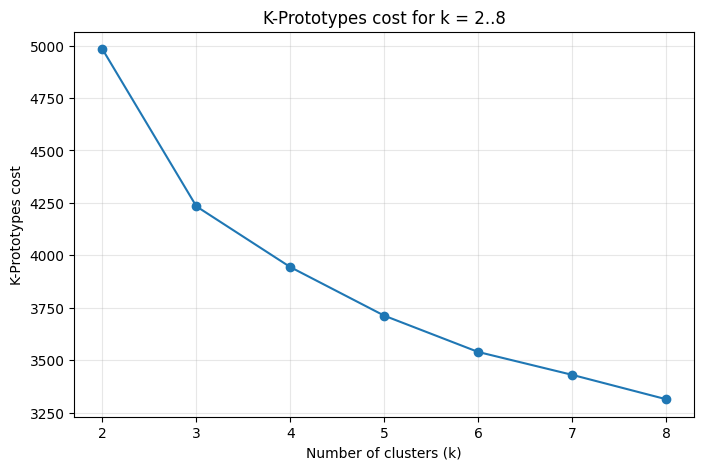


Automatically suggested k: 3

EMPLOYEE -> CLUSTER ASSIGNMENT (HEAD)
 employee  cluster
 21948553        1
 23811543        2
 24472838        0
 25478049        0
 25644407        1

POPULATION PER CLUSTER
 cluster  population  percentage
       0         632   41.415465
       1         721   47.247706
       2         173   11.336828

CLUSTER POPULATION
 cluster  population  percentage
       0         632   41.415465
       1         721   47.247706
       2         173   11.336828

NUMERICAL PROFILE (ORIGINAL SCALE)
        days_per_month_of_work_on_site                      QEMTRPDIST                              
                                  mean median min max count       mean  median    min      max count
cluster                                                                                             
0                             8.463608    8.0   2  31   632  48.878987  33.905  10.68  1218.77   632
1                             9.914008    8.0   3  31   721   8.59364

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes


# ============================================================
# CONFIG
# ============================================================
ID_COL = "employee"

numerical_cols = [
    "days_per_month_of_work_on_site",
    "QEMTRPDIST"
]

categorical_cols = [
    "age_group",
    "home_location_type",
    "office_location_type",
    "family_unit",
    "distance_of_pt_stop_closest_to_the_home",
    "gender",
    "working_time_arrangement",
    "accompanying_people",
    "during_journey_stops"
]

multi_choice_cols = [
    "available_means_transport"
]

K_RANGE = range(2, 9)   # 2 to 8 inclusive
RANDOM_STATE = 42
N_INIT = 10
INIT_METHOD = "Cao"
VERBOSE = 0


# ============================================================
# HELPERS
# ============================================================
def safe_log1p(series: pd.Series) -> pd.Series:
    """
    Convert to numeric, replace negatives with NaN, impute with median,
    then apply log1p for outlier compression.
    """
    s = pd.to_numeric(series, errors="coerce")
    s = s.mask(s < 0, np.nan)
    s = s.fillna(s.median())
    return np.log1p(s)


def split_multi_choice_column(series: pd.Series, prefix: str, sep: str = "^") -> pd.DataFrame:
    """
    Example:
      'car^bike^motorcycle'
    becomes:
      prefix__car = 'yes'/'no'
      prefix__bike = 'yes'/'no'
      prefix__motorcycle = 'yes'/'no'

    This is the right treatment because a multi-choice answer is a set
    of owned modes, not one single category.
    """
    s = series.fillna("").astype(str).str.strip()

    unique_options = set()
    for value in s:
        if value == "":
            continue
        parts = [p.strip() for p in value.split(sep) if p.strip()]
        unique_options.update(parts)

    unique_options = sorted(unique_options)

    out = pd.DataFrame(index=s.index)
    for opt in unique_options:
        out[f"{prefix}__{opt}"] = s.apply(
            lambda x: "yes" if opt in [p.strip() for p in x.split(sep) if p.strip()] else "no"
        )
    return out


def preprocess_for_kprototypes(
    df: pd.DataFrame,
    id_col: str,
    numerical_cols: list[str],
    categorical_cols: list[str],
    multi_choice_cols: list[str]
):
    """
    Returns:
      X_df                   preprocessed clustering matrix as DataFrame
      X_matrix               same as numpy object matrix for KPrototypes
      categorical_indices    positional indices of categorical columns
      employee_ids           original employee IDs kept aside
      df_with_clean_features copy of original df plus cleaned/transformed columns for profiling
      scaler                 fitted scaler for numerical cols
      expanded_multi_cols    new binary columns created from multi-choice fields
    """
    df = df.copy()

    # Keep employee IDs aside for final assignment
    employee_ids = df[id_col].copy()

    # Only work with the requested fields
    cols_to_use = numerical_cols + categorical_cols + multi_choice_cols
    X = df[cols_to_use].copy()

    # --------------------------
    # Numerical preprocessing
    # --------------------------
    for col in numerical_cols:
        X[col] = safe_log1p(X[col])

    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    # --------------------------
    # Standard categorical preprocessing
    # --------------------------
    for col in categorical_cols:
        X[col] = X[col].fillna("Missing").astype(str)

    # --------------------------
    # Multi-choice preprocessing
    # --------------------------
    expanded_multi_frames = []
    for col in multi_choice_cols:
        expanded = split_multi_choice_column(X[col], prefix=col, sep="^")
        expanded_multi_frames.append(expanded)

    X = X.drop(columns=multi_choice_cols)

    if expanded_multi_frames:
        expanded_multi_df = pd.concat(expanded_multi_frames, axis=1)
        X = pd.concat([X, expanded_multi_df], axis=1)
        expanded_multi_cols = list(expanded_multi_df.columns)
    else:
        expanded_multi_cols = []

    # All expanded multi-choice columns are categorical
    final_categorical_cols = categorical_cols + expanded_multi_cols

    # Final ordering: numerical first, then categorical
    final_cols = numerical_cols + final_categorical_cols
    X = X[final_cols].copy()

    # Make categorical columns strings
    for col in final_categorical_cols:
        X[col] = X[col].fillna("Missing").astype(str)

    # KPrototypes expects mixed-type object array
    X_matrix = X.to_numpy(dtype=object)

    categorical_indices = [X.columns.get_loc(col) for col in final_categorical_cols]

    # Build a copy of original DF with cleaned versions for easier profiling
    df_profile = df.copy()

    # Store transformed numerical values too, useful for profiling the model input space
    for col in numerical_cols:
        df_profile[f"{col}__log1p"] = safe_log1p(df[col])

    # Add expanded multi-choice columns to the profile DF as well
    for col in multi_choice_cols:
        expanded = split_multi_choice_column(df[col], prefix=col, sep="^")
        df_profile = pd.concat([df_profile, expanded], axis=1)

    return (
        X,
        X_matrix,
        categorical_indices,
        employee_ids,
        df_profile,
        scaler,
        expanded_multi_cols
    )


def fit_k_range(
    X_matrix,
    categorical_indices,
    k_range,
    random_state=42,
    n_init=10,
    init="Cao",
    verbose=0
):
    """
    Fits KPrototypes for each K and collects cost and labels.
    """
    rows = []
    fitted_models = {}

    for k in k_range:
        model = KPrototypes(
            n_clusters=k,
            init=init,
            n_init=n_init,
            random_state=random_state,
            verbose=verbose
        )
        labels = model.fit_predict(X_matrix, categorical=categorical_indices)

        fitted_models[k] = {
            "model": model,
            "labels": labels
        }

        rows.append({
            "k": k,
            "cost": model.cost_,
            "n_iter": model.n_iter_
        })

    results_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    results_df["cost_drop_abs"] = results_df["cost"].shift(1) - results_df["cost"]
    results_df["cost_drop_pct"] = (results_df["cost_drop_abs"] / results_df["cost"].shift(1)) * 100

    return results_df, fitted_models


def choose_k_elbow_like(results_df: pd.DataFrame) -> int:
    """
    Simple automatic heuristic:
    choose the K with the largest relative drop in cost before improvements flatten.

    This is only a helper, not a substitute for interpretation.
    """
    temp = results_df.copy()
    temp["next_drop_pct"] = temp["cost_drop_pct"].shift(-1)

    # fallback: if no drops can be computed
    if temp["cost_drop_pct"].notna().sum() == 0:
        return int(temp["k"].iloc[0])

    # largest cost reduction point among valid rows
    idx = temp["cost_drop_pct"].idxmax()
    return int(temp.loc[idx, "k"])


def build_cluster_assignment(employee_ids: pd.Series, labels: np.ndarray) -> pd.DataFrame:
    out = pd.DataFrame({
        "employee": employee_ids.values,
        "cluster": labels
    })
    return out


def cluster_population_table(clustered_df: pd.DataFrame, cluster_col: str = "cluster") -> pd.DataFrame:
    pop = clustered_df[cluster_col].value_counts().sort_index().rename("population").reset_index()
    pop.columns = [cluster_col, "population"]
    pop["percentage"] = 100 * pop["population"] / pop["population"].sum()
    return pop.sort_values(cluster_col).reset_index(drop=True)


def numerical_cluster_profile(
    clustered_df: pd.DataFrame,
    numerical_profile_cols: list[str],
    cluster_col: str = "cluster"
) -> pd.DataFrame:
    return clustered_df.groupby(cluster_col)[numerical_profile_cols].agg(["mean", "median", "min", "max", "count"])


def top_categories_per_cluster(
    clustered_df: pd.DataFrame,
    cols: list[str],
    cluster_col: str = "cluster",
    top_n: int = 3
) -> dict:
    """
    For each categorical column and each cluster, return top N category frequencies.
    """
    output = {}

    for col in cols:
        pieces = []
        for cluster_id, sub in clustered_df.groupby(cluster_col):
            vc = sub[col].fillna("Missing").astype(str).value_counts(dropna=False).head(top_n)
            tmp = vc.reset_index()
            tmp.columns = [col, "count"]
            tmp["cluster"] = cluster_id
            tmp["percentage"] = 100 * tmp["count"] / len(sub)
            pieces.append(tmp[["cluster", col, "count", "percentage"]])

        output[col] = pd.concat(pieces, ignore_index=True).sort_values(["cluster", "count"], ascending=[True, False])

    return output


def print_cluster_report(
    clustered_df: pd.DataFrame,
    original_numerical_cols: list[str],
    transformed_numerical_cols: list[str],
    categorical_profile_cols: list[str]
):
    print("\n" + "=" * 80)
    print("CLUSTER POPULATION")
    print("=" * 80)
    print(cluster_population_table(clustered_df).to_string(index=False))

    print("\n" + "=" * 80)
    print("NUMERICAL PROFILE (ORIGINAL SCALE)")
    print("=" * 80)
    print(numerical_cluster_profile(clustered_df, original_numerical_cols).to_string())

    print("\n" + "=" * 80)
    print("NUMERICAL PROFILE (LOG1P INPUT SPACE)")
    print("=" * 80)
    print(numerical_cluster_profile(clustered_df, transformed_numerical_cols).to_string())

    print("\n" + "=" * 80)
    print("TOP CATEGORIES PER CLUSTER")
    print("=" * 80)
    cat_tables = top_categories_per_cluster(clustered_df, categorical_profile_cols, top_n=3)

    for col, table in cat_tables.items():
        print(f"\n--- {col} ---")
        print(table.to_string(index=False))


# ============================================================
# MAIN PIPELINE
# ============================================================
# Example:
df = pd.read_csv("5_2023_urbanCategoryFound.csv",  encoding="ISO-8859-1")

# 1) Preprocess
(
    X_df,
    X_matrix,
    categorical_indices,
    employee_ids,
    df_profile,
    scaler,
    expanded_multi_cols
) = preprocess_for_kprototypes(
    df=df,
    id_col=ID_COL,
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,
    multi_choice_cols=multi_choice_cols
)

# 2) Fit K = 2..8
k_results, fitted_models = fit_k_range(
    X_matrix=X_matrix,
    categorical_indices=categorical_indices,
    k_range=K_RANGE,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    init=INIT_METHOD,
    verbose=VERBOSE
)

print("\nK SEARCH RESULTS")
print(k_results.to_string(index=False))

# 3) Plot elbow-like curve
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["cost"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("K-Prototypes cost")
plt.title("K-Prototypes cost for k = 2..8")
plt.grid(True, alpha=0.3)
plt.show()

# 4) Choose K
# Replace this with your manual choice after inspecting the plot if you want.
chosen_k = choose_k_elbow_like(k_results)
print(f"\nAutomatically suggested k: {chosen_k}")

# If you prefer to force a value after visual inspection, uncomment:
# chosen_k = 4

# 5) Get final model and labels
final_model = fitted_models[chosen_k]["model"]
final_labels = fitted_models[chosen_k]["labels"]

# 6) Bring back employee ID
cluster_assignment = build_cluster_assignment(employee_ids, final_labels)

print("\nEMPLOYEE -> CLUSTER ASSIGNMENT (HEAD)")
print(cluster_assignment.head().to_string(index=False))

# 7) Merge labels back to original/profile data
df_clustered = df_profile.copy()
df_clustered["cluster"] = final_labels

# 8) Population per cluster
population_df = cluster_population_table(df_clustered)
print("\nPOPULATION PER CLUSTER")
print(population_df.to_string(index=False))

# 9) Detailed cluster report
numerical_profile_original = numerical_cols
numerical_profile_transformed = [f"{c}__log1p" for c in numerical_cols]
categorical_profile_cols = categorical_cols + expanded_multi_cols

print_cluster_report(
    clustered_df=df_clustered,
    original_numerical_cols=numerical_profile_original,
    transformed_numerical_cols=numerical_profile_transformed,
    categorical_profile_cols=categorical_profile_cols
)

# 10) Optional: look at centroids directly from the fitted K-Prototypes model
print("\nFINAL MODEL COST:", final_model.cost_)
print("FINAL MODEL N_ITER:", final_model.n_iter_)
print("\nCLUSTER CENTROIDS (RAW MODEL OUTPUT):")
print(final_model.cluster_centroids_)

# 11) Optional export files
cluster_assignment.to_csv("employee_cluster_assignment.csv", index=False)
population_df.to_csv("cluster_population_summary.csv", index=False)
k_results.to_csv("kprototypes_k_search_results.csv", index=False)

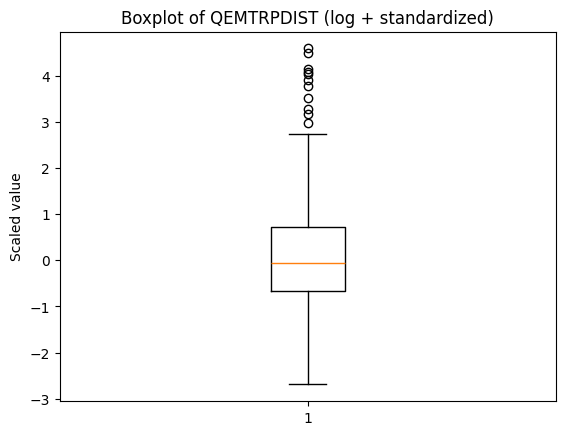

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(X_df["QEMTRPDIST"])
plt.title("Boxplot of QEMTRPDIST (log + standardized)")
plt.ylabel("Scaled value")
plt.show()